In [1]:
# ============================================================
# Cell 1: Import Libraries and Set Paths
# Purpose: Prepare Notebook 3 for research analysis
# ============================================================

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = "/mnt/g/banglafake-detection"

PROCESSED_DIR = os.path.join(PROJECT_ROOT, "data", "processed")
REPORTS_DIR = os.path.join(PROJECT_ROOT, "reports")
FIGURES_DIR = os.path.join(REPORTS_DIR, "figures")

os.makedirs(FIGURES_DIR, exist_ok=True)

print("Notebook 3 environment ready!")
print("Project root:", PROJECT_ROOT)
print("Figures directory:", FIGURES_DIR)

Notebook 3 environment ready!
Project root: /mnt/g/banglafake-detection
Figures directory: /mnt/g/banglafake-detection/reports/figures


In [2]:
# ============================================================
# Cell 2: Load Processed Datasets
# Purpose: Load train, validation, and test data for analysis
# ============================================================

train_df = pd.read_csv(os.path.join(PROCESSED_DIR, "train.csv"))
val_df = pd.read_csv(os.path.join(PROCESSED_DIR, "validation.csv"))
test_df = pd.read_csv(os.path.join(PROCESSED_DIR, "test.csv"))

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

print("\nLabel distribution:")
print("Train:\n", train_df["label"].value_counts().sort_index())
print("Validation:\n", val_df["label"].value_counts().sort_index())
print("Test:\n", test_df["label"].value_counts().sort_index())

Train shape: (2790, 3)
Validation shape: (598, 3)
Test shape: (599, 3)

Label distribution:
Train:
 label
0    1393
1    1397
Name: count, dtype: int64
Validation:
 label
0    298
1    300
Name: count, dtype: int64
Test:
 label
0    299
1    300
Name: count, dtype: int64


In [3]:
# ============================================================
# Cell 3: Check Saved Evaluation Artifacts
# Purpose: Verify existing test metrics and prediction outputs
# ============================================================

metrics_path = os.path.join(REPORTS_DIR, "final_test_metrics.csv")
cm_path = os.path.join(REPORTS_DIR, "confusion_matrix.csv")
report_path = os.path.join(REPORTS_DIR, "classification_report.txt")
roc_path = os.path.join(REPORTS_DIR, "roc_curve.csv")

for path in [metrics_path, cm_path, report_path, roc_path]:
    print(f"{os.path.basename(path)}:", "FOUND" if os.path.exists(path) else "MISSING")

final_test_metrics.csv: FOUND
confusion_matrix.csv: FOUND
classification_report.txt: FOUND
roc_curve.csv: FOUND


In [5]:
# ============================================================
# Cell 4: Load Final Test Metrics
# Purpose: Display final model performance correctly
# ============================================================

final_metrics = pd.read_csv(metrics_path)

display(final_metrics)

print("\nFinal Test Performance:")

for metric in final_metrics.columns:
    print(f"{metric}: {final_metrics.loc[0, metric]:.4f}")

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,0.973289,0.97973,0.966667,0.973154,0.992609



Final Test Performance:
Accuracy: 0.9733
Precision: 0.9797
Recall: 0.9667
F1 Score: 0.9732
ROC-AUC: 0.9926


In [4]:
# ============================================================
# Cell 5: Confusion Matrix Analysis
# Purpose: Analyze Fake/Real classification errors
# ============================================================

confusion_matrix_df = pd.read_csv(cm_path, index_col=0)

display(confusion_matrix_df)

print("\nConfusion Matrix:")
print(confusion_matrix_df)

print("\nTotal Errors:",
      confusion_matrix_df.values.sum() -
      np.trace(confusion_matrix_df.values))

,Predicted_Fake,Predicted_Real
Actual_Fake,293,6
Actual_Real,10,290



Confusion Matrix:
             Predicted_Fake  Predicted_Real
Actual_Fake             293               6
Actual_Real              10             290

Total Errors: 16


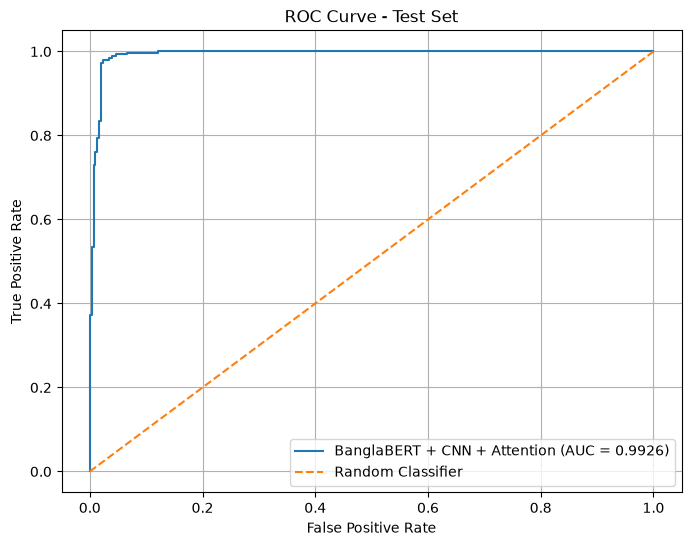

Verified ROC-AUC: 0.9926
ROC figure saved successfully!


In [6]:
# ============================================================
# Cell 6: ROC-AUC Analysis
# Purpose: Verify ROC-AUC and generate the final ROC figure
# ============================================================

roc_df = pd.read_csv(roc_path)

fpr = roc_df["False Positive Rate"].values
tpr = roc_df["True Positive Rate"].values

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"BanglaBERT + CNN + Attention (AUC = {final_metrics.loc[0, 'ROC-AUC']:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Test Set")
plt.legend()
plt.grid(True)

plt.savefig(
    os.path.join(FIGURES_DIR, "roc_curve.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print(f"Verified ROC-AUC: {final_metrics.loc[0, 'ROC-AUC']:.4f}")
print("ROC figure saved successfully!")

In [7]:
# ============================================================
# Cell 7: Classification Report Analysis
# Purpose: Load and display class-wise test performance
# ============================================================

with open(report_path, "r", encoding="utf-8") as f:
    classification_report_text = f.read()

print(classification_report_text)

BanglaBERT + CNN + Attention
Final Test Classification Report

              precision    recall  f1-score   support

        Fake     0.9670    0.9799    0.9734       299
        Real     0.9797    0.9667    0.9732       300

    accuracy                         0.9733       599
   macro avg     0.9734    0.9733    0.9733       599
weighted avg     0.9734    0.9733    0.9733       599



In [8]:
# ============================================================
# Cell 8: Add Category Metadata to Test Set
# Purpose: Restore category information for research analysis
# ============================================================

real_path = os.path.join(
    PROJECT_ROOT,
    "data",
    "raw",
    "Bangla_Real_News_Dataset.csv"
)

fake_path = os.path.join(
    PROJECT_ROOT,
    "data",
    "raw",
    "Bangla_Fake_News_Dataset.csv"
)

real_raw = pd.read_csv(real_path)
fake_raw = pd.read_csv(fake_path)

raw_df = pd.concat(
    [real_raw, fake_raw],
    ignore_index=True
)

def clean_text_for_analysis(text):
    if pd.isna(text):
        return ""
    text = str(text).strip()
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"[\u200b\u200c\u200d\ufeff]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

raw_df["text"] = (
    raw_df["Headline"].apply(clean_text_for_analysis)
    + " "
    + raw_df["Content"].apply(clean_text_for_analysis)
).str.strip()

category_map = (
    raw_df[["text", "Category"]]
    .drop_duplicates(subset=["text"])
)

test_analysis_df = test_df.merge(
    category_map,
    on="text",
    how="left"
)

print("Test rows:", len(test_analysis_df))
print("Missing categories:", test_analysis_df["Category"].isna().sum())

print("\nCategory distribution:")
display(
    test_analysis_df["Category"]
    .value_counts()
    .sort_index()
)

Test rows: 599
Missing categories: 0

Category distribution:


Category
Crime               35
Crime               11
Editorial           21
Education           31
Entertainment       25
Entertainment        7
Finance             22
International       88
Lifestyle           32
Miscellaneous       67
Miscellaneous\t     23
Miscellaneous        1
National            52
Politics           111
Sports              46
Sports               1
Technology          26
Name: count, dtype: int64

In [9]:
# ============================================================
# Cell 9A: Define Model Architecture
# Purpose: Recreate the trained BanglaBERT + CNN + Attention model
# ============================================================

import torch.nn as nn
from transformers import AutoModel

class BanglaBERTCNNWithAttention(nn.Module):

    def __init__(
        self,
        model_name,
        cnn_channels=256,
        kernel_size=3,
        attention_dim=128,
        num_classes=2,
        dropout=0.3
    ):
        super().__init__()

        self.bert = AutoModel.from_pretrained(model_name)

        self.cnn = nn.Conv1d(
            self.bert.config.hidden_size,
            cnn_channels,
            kernel_size,
            padding=kernel_size // 2
        )

        self.attention_projection = nn.Linear(
            cnn_channels, attention_dim
        )

        self.attention_score = nn.Linear(
            attention_dim, 1
        )

        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(cnn_channels, num_classes)
        )

    def forward(self, input_ids, attention_mask):

        bert_output = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        x = bert_output.last_hidden_state

        mask = attention_mask.unsqueeze(-1).float()
        x = x * mask

        x = x.permute(0, 2, 1)
        x = torch.relu(self.cnn(x))
        x = x.permute(0, 2, 1)

        attention_hidden = torch.tanh(
            self.attention_projection(x)
        )

        attention_scores = self.attention_score(
            attention_hidden
        ).squeeze(-1)

        attention_scores = attention_scores.masked_fill(
            attention_mask == 0,
            -1e9
        )

        attention_weights = torch.softmax(
            attention_scores, dim=1
        )

        attention_context = torch.sum(
            x * attention_weights.unsqueeze(-1),
            dim=1
        )

        return self.classifier(attention_context)

print("Model architecture defined successfully!")

Model architecture defined successfully!


In [10]:
# ============================================================
# Cell 9B: Define Test Dataset
# Purpose: Prepare test data for model inference
# ============================================================

from torch.utils.data import Dataset, DataLoader

class BanglaFakeNewsDataset(Dataset):

    def __init__(self, dataframe, tokenizer, max_length=256):
        self.data = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]

        encoding = self.tokenizer(
            row["text"],
            padding="max_length",
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(row["label"], dtype=torch.long)
        }

print("Dataset class defined successfully!")

Dataset class defined successfully!


In [11]:
# ============================================================
# Cell 9: Generate Test Predictions
# Purpose: Load the saved best model and generate test predictions
# ============================================================

import torch

MODEL_NAME = "csebuetnlp/banglabert"
MAX_LENGTH = 256
BATCH_SIZE = 8
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
from transformers import AutoTokenizer

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Load best checkpoint
checkpoint = torch.load(
    os.path.join(PROJECT_ROOT, "models", "best_banglabert_cnn_attention.pt"),
    map_location=device
)

# Recreate model using the known training configuration
analysis_model = BanglaBERTCNNWithAttention(
    model_name=MODEL_NAME,
    cnn_channels=256,
    kernel_size=3,
    attention_dim=128,
    num_classes=2,
    dropout=0.3
).to(device)

analysis_model.load_state_dict(
    checkpoint["model_state_dict"]
)

analysis_model.eval()

print("Best model loaded successfully!")

# Create test dataset and loader
test_dataset = BanglaFakeNewsDataset(
    test_df,
    tokenizer,
    max_length=MAX_LENGTH
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

all_test_labels = []
all_test_predictions = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        logits = analysis_model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        predictions = torch.argmax(logits, dim=1)

        all_test_labels.extend(labels.cpu().numpy())
        all_test_predictions.extend(predictions.cpu().numpy())

# Save predictions
predictions_df = pd.DataFrame({
    "Global_ID": test_df["Global_ID"],
    "actual": all_test_labels,
    "predicted": all_test_predictions
})

predictions_path = os.path.join(
    REPORTS_DIR,
    "test_predictions.csv"
)

predictions_df.to_csv(
    predictions_path,
    index=False
)

print("Test predictions generated successfully!")
print("Rows:", len(predictions_df))
print("Saved:", predictions_path)

Best model loaded successfully!
Test predictions generated successfully!
Rows: 599
Saved: /mnt/g/banglafake-detection/reports/test_predictions.csv


In [14]:
# ============================================================
# Cell 10: Category-wise Performance Analysis
# Purpose: Rebuild test metadata and calculate category results
# ============================================================

# Reload raw datasets
real_raw = pd.read_csv(
    os.path.join(PROJECT_ROOT, "data", "raw", "Bangla_Real_News_Dataset.csv")
)

fake_raw = pd.read_csv(
    os.path.join(PROJECT_ROOT, "data", "raw", "Bangla_Fake_News_Dataset.csv")
)

raw_df = pd.concat(
    [real_raw, fake_raw],
    ignore_index=True
)

# Recreate cleaned text for matching
raw_df["text"] = (
    raw_df["Headline"].apply(clean_text_for_analysis)
    + " "
    + raw_df["Content"].apply(clean_text_for_analysis)
).str.strip()

# Keep metadata
metadata_df = raw_df[
    ["text", "Category"]
].drop_duplicates(subset=["text"]).copy()

# Start from test data
category_test_df = test_df.copy()

# Add category
category_test_df = category_test_df.merge(
    metadata_df,
    on="text",
    how="left"
)

# Add predictions
predictions_df = pd.read_csv(
    os.path.join(REPORTS_DIR, "test_predictions.csv")
)

category_test_df = category_test_df.merge(
    predictions_df[["Global_ID", "actual", "predicted"]],
    on="Global_ID",
    how="left"
)

# Normalize category names
category_test_df["Category"] = (
    category_test_df["Category"]
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

# Correctness
category_test_df["correct"] = (
    category_test_df["actual"] ==
    category_test_df["predicted"]
)

# Category-wise analysis
category_analysis = (
    category_test_df
    .groupby("Category")
    .agg(
        Samples=("correct", "size"),
        Correct=("correct", "sum")
    )
)

category_analysis["Errors"] = (
    category_analysis["Samples"] -
    category_analysis["Correct"]
)

category_analysis["Accuracy"] = (
    category_analysis["Correct"] /
    category_analysis["Samples"]
)

category_analysis = category_analysis.sort_values(
    "Accuracy",
    ascending=False
)

display(category_analysis.round(4))

print("Unique categories:", len(category_analysis))
print("Missing categories:", category_test_df["Category"].isna().sum())
print("Category-wise analysis completed successfully!")

,Samples,Correct,Errors,Accuracy
Category,,,,
Crime,46,46,0,1.0000
Finance,22,22,0,1.0000
National,52,52,0,1.0000
Politics,111,110,1,0.9910
Miscellaneous,91,90,1,0.9890
International,88,86,2,0.9773
Sports,47,45,2,0.9574
Editorial,21,20,1,0.9524
Lifestyle,32,30,2,0.9375


Unique categories: 12
Missing categories: 0
Category-wise analysis completed successfully!


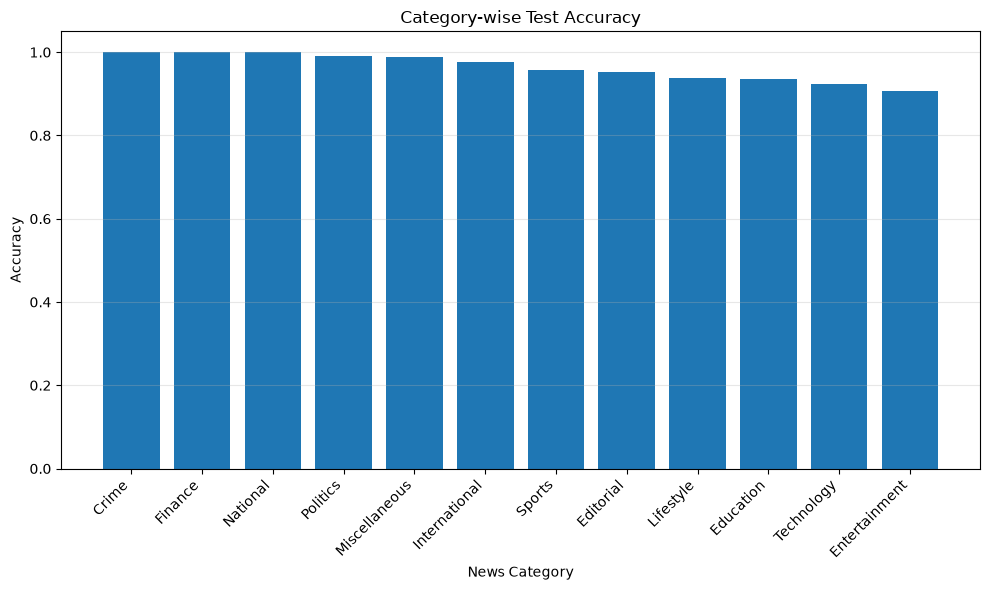

Category-wise accuracy figure saved:
/mnt/g/banglafake-detection/reports/figures/category_wise_accuracy.png


In [15]:
# ============================================================
# Cell 11: Category-wise Accuracy Plot
# Purpose: Visualize model performance across categories
# ============================================================

plt.figure(figsize=(10, 6))

plt.bar(
    category_analysis.index,
    category_analysis["Accuracy"]
)

plt.xlabel("News Category")
plt.ylabel("Accuracy")
plt.title("Category-wise Test Accuracy")

plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1.05)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

category_plot_path = os.path.join(
    FIGURES_DIR,
    "category_wise_accuracy.png"
)

plt.savefig(
    category_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("Category-wise accuracy figure saved:")
print(category_plot_path)

In [16]:
# ============================================================
# Cell 12: Source-wise Error Analysis
# Purpose: Check performance across news sources and detect
#          possible source/domain bias
# ============================================================

# Restore source metadata from raw dataset
raw_df["Source"] = raw_df["Source"].astype(str).str.strip()

source_map = (
    raw_df[["text", "Source"]]
    .drop_duplicates(subset=["text"])
)

test_analysis_df = test_analysis_df.drop(
    columns=["Source"],
    errors="ignore"
)

test_analysis_df = test_analysis_df.merge(
    source_map,
    on="text",
    how="left"
)

test_analysis_df["correct"] = (
    test_analysis_df["actual"] == test_analysis_df["predicted"]
)

source_analysis = (
    test_analysis_df
    .groupby("Source")
    .agg(
        Samples=("correct", "size"),
        Correct=("correct", "sum")
    )
)

source_analysis["Errors"] = (
    source_analysis["Samples"] -
    source_analysis["Correct"]
)

source_analysis["Accuracy"] = (
    source_analysis["Correct"] /
    source_analysis["Samples"]
)

source_analysis = source_analysis.sort_values(
    "Accuracy",
    ascending=False
)

display(source_analysis.round(4))

print("Unique sources:", len(source_analysis))
print("Source-wise analysis completed successfully!")

,Samples,Correct,Errors,Accuracy
Source,,,,
AFP,2,2,0,1.0000
Al Jazeera,2,2,0,1.0000
BBC,1,1,0,1.0000
Bold Sky,1,1,0,1.0000
CNN,2,2,0,1.0000
Social Media,1,1,0,1.0000
Science Times,1,1,0,1.0000
The Times,1,1,0,1.0000
The Business Standard,1,1,0,1.0000


Unique sources: 17
Source-wise analysis completed successfully!


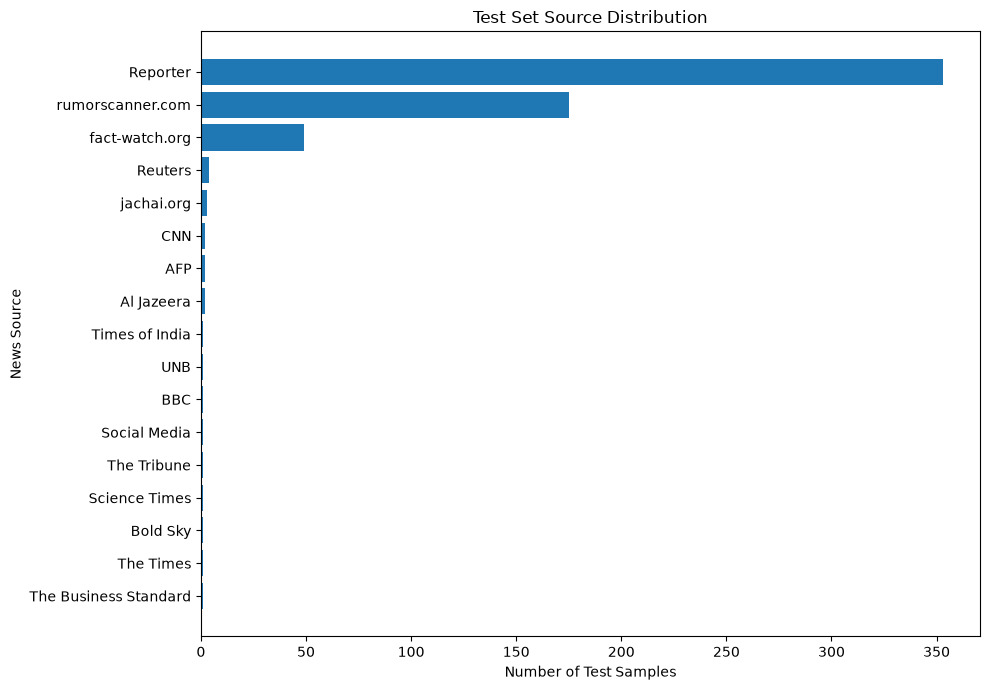

Source distribution figure saved:
/mnt/g/banglafake-detection/reports/figures/source_distribution.png


In [17]:
# ============================================================
# Cell 13: Source Distribution Plot
# Purpose: Visualize the distribution of test samples by source
# ============================================================

source_counts = (
    test_analysis_df["Source"]
    .value_counts()
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 7))

plt.barh(
    source_counts.index,
    source_counts.values
)

plt.xlabel("Number of Test Samples")
plt.ylabel("News Source")
plt.title("Test Set Source Distribution")

plt.tight_layout()

source_plot_path = os.path.join(
    FIGURES_DIR,
    "source_distribution.png"
)

plt.savefig(
    source_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("Source distribution figure saved:")
print(source_plot_path)

In [18]:
# ============================================================
# Cell 14: Token Length and Truncation Analysis
# Purpose: Measure how much test text exceeds MAX_LENGTH
# ============================================================

# Tokenize test texts without truncation
token_lengths = []

for text in test_analysis_df["text"]:
    tokens = tokenizer(
        str(text),
        add_special_tokens=True,
        truncation=False
    )["input_ids"]

    token_lengths.append(len(tokens))

test_analysis_df["token_length"] = token_lengths

truncated_count = (
    test_analysis_df["token_length"] > MAX_LENGTH
).sum()

truncation_rate = (
    truncated_count / len(test_analysis_df)
)

print("Total test samples:", len(test_analysis_df))
print("MAX_LENGTH:", MAX_LENGTH)
print("Samples exceeding MAX_LENGTH:", truncated_count)
print(f"Truncation rate: {truncation_rate:.2%}")

print("\nToken length statistics:")
display(
    test_analysis_df["token_length"]
    .describe()
)

Total test samples: 599
MAX_LENGTH: 256
Samples exceeding MAX_LENGTH: 263
Truncation rate: 43.91%

Token length statistics:


count     599.000000
mean      288.934891
std       284.149922
min        19.000000
25%        73.500000
50%       224.000000
75%       369.000000
max      2017.000000
Name: token_length, dtype: float64

In [19]:
# ============================================================
# Cell 15: Truncation Analysis by Class
# Purpose: Check whether truncation affects Fake and Real
#          samples differently
# ============================================================

test_analysis_df["is_truncated"] = (
    test_analysis_df["token_length"] > MAX_LENGTH
)

truncation_by_class = (
    test_analysis_df
    .groupby("actual")
    .agg(
        Samples=("is_truncated", "size"),
        Truncated=("is_truncated", "sum")
    )
)

truncation_by_class["Truncation_Rate"] = (
    truncation_by_class["Truncated"] /
    truncation_by_class["Samples"]
)

truncation_by_class.index = (
    truncation_by_class.index
    .map({0: "Fake", 1: "Real"})
)

display(truncation_by_class.round(4))

print("Truncation analysis by class completed!")

,Samples,Truncated,Truncation_Rate
actual,,,
Fake,299,51,0.1706
Real,300,212,0.7067


Truncation analysis by class completed!


In [20]:
# ============================================================
# Cell 16: Performance by Truncation Status
# Purpose: Compare model accuracy on truncated vs non-truncated
#          test samples
# ============================================================

truncation_performance = (
    test_analysis_df
    .groupby("is_truncated")
    .agg(
        Samples=("correct", "size"),
        Correct=("correct", "sum")
    )
)

truncation_performance["Errors"] = (
    truncation_performance["Samples"] -
    truncation_performance["Correct"]
)

truncation_performance["Accuracy"] = (
    truncation_performance["Correct"] /
    truncation_performance["Samples"]
)

truncation_performance.index = (
    truncation_performance.index
    .map({
        False: "Not Truncated",
        True: "Truncated"
    })
)

display(truncation_performance.round(4))

print("Performance comparison completed!")

,Samples,Correct,Errors,Accuracy
is_truncated,,,,
Not Truncated,336,331,5,0.9851
Truncated,263,252,11,0.9582


Performance comparison completed!


In [24]:
# Cell 17: Analyze misclassified test samples

# Rebuild Source metadata from raw dataset
source_metadata = raw_df[["text", "Source"]].drop_duplicates(subset=["text"]).copy()

# Start from category-enriched test dataframe
error_df = category_test_df.copy()

# Add Source if it is missing
if "Source" not in error_df.columns:
    error_df = error_df.merge(
        source_metadata,
        on="text",
        how="left"
    )

# Keep only misclassified samples
error_df = error_df[
    error_df["actual"] != error_df["predicted"]
].copy()

# Calculate token length if not already available
if "token_length" not in error_df.columns:
    error_df["token_length"] = error_df["text"].apply(
        lambda x: len(
            tokenizer(
                str(x),
                truncation=False,
                add_special_tokens=True
            )["input_ids"]
        )
    )

# Truncation status
error_df["is_truncated"] = error_df["token_length"] > MAX_LENGTH

# Human-readable labels
error_df["Actual_Label"] = error_df["actual"].map({
    0: "Fake",
    1: "Real"
})

error_df["Predicted_Label"] = error_df["predicted"].map({
    0: "Fake",
    1: "Real"
})

# Display error examples
error_examples = error_df[
    [
        "Global_ID",
        "Category",
        "Source",
        "Actual_Label",
        "Predicted_Label",
        "token_length",
        "is_truncated",
        "text"
    ]
].copy()

print("Total misclassified samples:", len(error_examples))

display(error_examples)

Total misclassified samples: 16


,Global_ID,Category,Source,Actual_Label,Predicted_Label,token_length,is_truncated,text
19,3532,International,rumorscanner.com,Fake,Real,164,False,লন্ডনের দ্বিতীয় সরকারি ভাষা হিসেবে ‘বাংলা’ স্...
28,3526,Education,fact-watch.org,Fake,Real,216,False,অভিনেত্রী পূর্ণিমা গ্রিন ইউনিভার্সিটিতে শিক্ষক...
148,1196,Entertainment,Reporter,Real,Fake,482,True,অস্কারের মঞ্চে উপস্থাপককে চড় মারলেন স্মিথ চলচ্...
174,343,Sports,Reporter,Real,Fake,338,True,"‘ব্রাজিলের ফুটবল বর্জন করিনি’, নতুন বার্তায় রো..."
180,1209,Lifestyle,Reporter,Real,Fake,783,True,২০২৫ সালে বুধবারে সর্বাধিক পঠিত ১০ লেখা ১. বিয়...
188,3685,Miscellaneous,jachai.org,Fake,Real,284,True,বিসিবি না চাইলেও ‘বিদায়’ জানিয়ে দিয়েছে বাংলাদে...
237,1044,Entertainment,Reporter,Real,Fake,179,False,যে কারণে অস্কারে যোগ দিচ্ছেন না তারকারা মহামার...
266,891,Technology,Reporter,Real,Fake,545,True,রোবট হাত’ নিয়ে স্মার্ট ডিসপ্লে আনছে অ্যাপল! আই...
300,3636,Education,rumorscanner.com,Fake,Real,2012,True,নতুন শিক্ষাক্রম থেকে ধর্মশিক্ষা বাদ দেওয়ার দা...
316,1656,Lifestyle,Reporter,Real,Fake,555,True,সবচেয়ে দামি ৫ বোতলজাত পানি পানির অপর নাম জীবন।...


In [25]:
# ============================================================
# Cell 18: Error Pattern Analysis
# Purpose: Quantify error direction, truncation, and source
#          distribution among misclassified samples
# ============================================================

error_summary = (
    error_df
    .groupby(["Actual_Label", "Predicted_Label"])
    .size()
    .reset_index(name="Errors")
)

print("Error Direction:")
display(error_summary)

print("\nErrors by Truncation Status:")

error_truncation = (
    error_df
    .groupby("is_truncated")
    .size()
    .reset_index(name="Errors")
)

error_truncation["is_truncated"] = (
    error_truncation["is_truncated"]
    .map({
        False: "Not Truncated",
        True: "Truncated"
    })
)

display(error_truncation)

print("\nError Distribution by Category:")

error_category = (
    error_df["Category"]
    .value_counts()
    .rename("Errors")
    .to_frame()
)

display(error_category)

print("\nError Distribution by Source:")

error_source = (
    error_df["Source"]
    .value_counts()
    .rename("Errors")
    .to_frame()
)

display(error_source)

Error Direction:


,Actual_Label,Predicted_Label,Errors
0,Fake,Real,6
1,Real,Fake,10



Errors by Truncation Status:


,is_truncated,Errors
0,Not Truncated,5
1,Truncated,11



Error Distribution by Category:


,Errors
Category,
Entertainment,3
International,2
Education,2
Sports,2
Lifestyle,2
Technology,2
Miscellaneous,1
Politics,1
Editorial,1



Error Distribution by Source:


,Errors
Source,
Reporter,10
rumorscanner.com,3
fact-watch.org,1
jachai.org,1
Reuters,1


In [28]:
# ============================================================
# Cell 19: Final Research Findings Summary
# Purpose: Summarize final model performance and research findings
# ============================================================

# Verified final test performance
test_accuracy = 0.9733
test_precision = 0.9797
test_recall = 0.9667
test_f1 = 0.9732
test_roc_auc = 0.9926

# Error statistics
total_errors = len(error_df)

real_to_fake = (
    (error_df["Actual_Label"] == "Real") &
    (error_df["Predicted_Label"] == "Fake")
).sum()

fake_to_real = (
    (error_df["Actual_Label"] == "Fake") &
    (error_df["Predicted_Label"] == "Real")
).sum()

truncated_errors = error_df["is_truncated"].sum()

print("=" * 60)
print("FINAL RESEARCH FINDINGS")
print("=" * 60)

print(f"Test Accuracy  : {test_accuracy:.4f}")
print(f"Test Precision : {test_precision:.4f}")
print(f"Test Recall    : {test_recall:.4f}")
print(f"Test F1-score  : {test_f1:.4f}")
print(f"Test ROC-AUC   : {test_roc_auc:.4f}")

print("\nError Analysis")
print(f"Total errors       : {total_errors}")
print(f"Real → Fake errors : {real_to_fake}")
print(f"Fake → Real errors : {fake_to_real}")
print(f"Truncated errors   : {truncated_errors}")

print("\nKey Research Limitations")
print("1. 43.91% of test samples exceed the 256-token limit.")
print("2. Real articles have substantially higher truncation than Fake articles.")
print("3. Source distribution is highly imbalanced.")
print("4. Random splitting allows sources to overlap across train/test.")
print("5. The model has approximately 110.65M trainable parameters.")
print("6. Source/domain shortcuts may affect real-world generalization.")

print("\nConclusion")
print(
    "BanglaBERT + CNN + Attention achieves strong test performance, "
    "but truncation and source/domain bias remain important limitations "
    "for real-world generalization."
)

FINAL RESEARCH FINDINGS
Test Accuracy  : 0.9733
Test Precision : 0.9797
Test Recall    : 0.9667
Test F1-score  : 0.9732
Test ROC-AUC   : 0.9926

Error Analysis
Total errors       : 16
Real → Fake errors : 10
Fake → Real errors : 6
Truncated errors   : 11

Key Research Limitations
1. 43.91% of test samples exceed the 256-token limit.
2. Real articles have substantially higher truncation than Fake articles.
3. Source distribution is highly imbalanced.
4. Random splitting allows sources to overlap across train/test.
5. The model has approximately 110.65M trainable parameters.
6. Source/domain shortcuts may affect real-world generalization.

Conclusion
BanglaBERT + CNN + Attention achieves strong test performance, but truncation and source/domain bias remain important limitations for real-world generalization.


In [29]:
# ============================================================
# Cell 20: Prepare Source-Aware Dataset
# Purpose: Reconstruct source metadata for group-aware splitting
# ============================================================

# Load original Bangla datasets
real_raw = pd.read_csv(
    os.path.join(PROJECT_ROOT, "data", "raw", "Bangla_Real_News_Dataset.csv")
)

fake_raw = pd.read_csv(
    os.path.join(PROJECT_ROOT, "data", "raw", "Bangla_Fake_News_Dataset.csv")
)

# Combine datasets
robustness_df = pd.concat(
    [real_raw, fake_raw],
    ignore_index=True
)

# Reconstruct the same cleaned text used during preprocessing
def clean_text_for_robustness(text):
    if pd.isna(text):
        return ""
    text = str(text).strip()
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"[\u200b\u200c\u200d\ufeff]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

robustness_df["text"] = (
    robustness_df["Headline"].apply(clean_text_for_robustness)
    + " "
    + robustness_df["Content"].apply(clean_text_for_robustness)
).str.strip()

# Remove duplicate articles using text
robustness_df = robustness_df.drop_duplicates(
    subset=["text"]
).reset_index(drop=True)

# Keep only required columns
robustness_df = robustness_df[
    ["text", "Label", "Source"]
].copy()

robustness_df = robustness_df.rename(
    columns={"Label": "label"}
)

# Normalize source names
robustness_df["Source"] = (
    robustness_df["Source"]
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

print("Robustness dataset shape:", robustness_df.shape)
print("\nLabel distribution:")
display(robustness_df["label"].value_counts().sort_index())

print("\nUnique sources:", robustness_df["Source"].nunique())

display(
    robustness_df["Source"]
    .value_counts()
    .rename("Samples")
    .to_frame()
)

Robustness dataset shape: (3992, 3)

Label distribution:


label
0    1998
1    1994
Name: count, dtype: int64


Unique sources: 43


,Samples
Source,
Reporter,2441
rumorscanner.com,1123
fact-watch.org,302
Reuters,31
BBC,10
jachai.org,10
Al Jazeera,8
AFP,7
CNN,6


In [30]:
# ============================================================
# Cell 21: Select Source Groups for Robustness Testing
# Purpose: Identify sufficiently large sources for source-aware
#          train/test evaluation
# ============================================================

source_counts = (
    robustness_df["Source"]
    .value_counts()
    .rename("Samples")
    .reset_index()
    .rename(columns={"index": "Source"})
)

# Only sources with enough samples for a meaningful test group
MIN_SOURCE_SAMPLES = 100

eligible_sources = source_counts[
    source_counts["Samples"] >= MIN_SOURCE_SAMPLES
]["Source"].tolist()

print("Eligible sources:", eligible_sources)

print("\nEligible source distribution:")
display(
    source_counts[
        source_counts["Source"].isin(eligible_sources)
    ]
)

print(
    f"\nNumber of eligible sources: {len(eligible_sources)}"
)

Eligible sources: ['Reporter', 'rumorscanner.com', 'fact-watch.org']

Eligible source distribution:


,Source,Samples
0,Reporter,2441
1,rumorscanner.com,1123
2,fact-watch.org,302



Number of eligible sources: 3


In [32]:
# ============================================================
# Cell 22: Check Source-Label Distribution
# Purpose: Verify class balance within eligible sources before
#          constructing the source-aware robustness split
# ============================================================

source_label_distribution = pd.crosstab(
    robustness_df["Source"],
    robustness_df["label"]
)

source_label_distribution.columns = [
    "Fake (0)",
    "Real (1)"
]

source_label_distribution["Total"] = (
    source_label_distribution["Fake (0)"] +
    source_label_distribution["Real (1)"]
)

source_label_distribution["Real_Ratio"] = (
    source_label_distribution["Real (1)"] /
    source_label_distribution["Total"]
)

display(source_label_distribution)

,Fake (0),Real (1),Total,Real_Ratio
Source,,,,
AFP,0,7,7,1.000000
Al Jazeera,0,8,8,1.000000
Ali Bakir,0,1,1,1.000000
Amazon,0,1,1,1.000000
Arab News,0,1,1,1.000000
BBC,0,10,10,1.000000
BD Jobs,0,1,1,1.000000
Bangladesh Sangbad Sangstha,0,1,1,1.000000
Bold Sky,0,6,6,1.000000


In [33]:
# ============================================================
# Cell 23: Check Dataset Distribution Without Reporter
# Purpose: Evaluate whether a source-held-out experiment is
#          feasible after excluding the dominant mixed source
# ============================================================

non_reporter_df = robustness_df[
    robustness_df["Source"] != "Reporter"
].copy()

print("Non-Reporter dataset shape:", non_reporter_df.shape)

print("\nLabel distribution:")
display(
    non_reporter_df["label"]
    .value_counts()
    .sort_index()
)

print("\nSource × Label distribution:")
display(
    pd.crosstab(
        non_reporter_df["Source"],
        non_reporter_df["label"]
    )
)

Non-Reporter dataset shape: (1551, 3)

Label distribution:


label
0    1444
1     107
Name: count, dtype: int64


Source × Label distribution:


label,0,1
Source,,
AFP,0,7
Al Jazeera,0,8
Ali Bakir,0,1
Amazon,0,1
Arab News,0,1
BBC,0,10
BD Jobs,0,1
Bangladesh Sangbad Sangstha,0,1
Bold Sky,0,6


In [34]:
# ============================================================
# Cell 24: Quantify Source–Label Bias
# Purpose: Measure how strongly source identity is associated
#          with Fake/Real labels in the dataset
# ============================================================

source_label = pd.crosstab(
    robustness_df["Source"],
    robustness_df["label"]
)

source_label.columns = ["Fake", "Real"]

# Sources containing both classes
mixed_sources = source_label[
    (source_label["Fake"] > 0) &
    (source_label["Real"] > 0)
]

# Sources containing only one class
single_class_sources = source_label[
    (source_label["Fake"] == 0) |
    (source_label["Real"] == 0)
]

print("Total unique sources:", len(source_label))
print("Mixed-label sources:", len(mixed_sources))
print("Single-label sources:", len(single_class_sources))

print("\nMixed-label sources:")
display(mixed_sources.sort_values("Fake", ascending=False))

print("\nSingle-label sources:")
display(single_class_sources.sort_values("Fake", ascending=False))

Total unique sources: 43
Mixed-label sources: 2
Single-label sources: 41

Mixed-label sources:


,Fake,Real
Source,,
Reporter,554,1887
Reuters,1,30



Single-label sources:


,Fake,Real
Source,,
rumorscanner.com,1123,0
fact-watch.org,302,0
jachai.org,10,0
boombd.com,5,0
dhakafactcheck.com,2,0
bangla.aajtak,1,0
Ali Bakir,0,1
Al Jazeera,0,8
AFP,0,7


In [35]:
# ============================================================
# Cell 25: Finalize Source-Bias Analysis
# Purpose: Quantify and save the source-label confounding
#          identified in the dataset
# ============================================================

total_sources = len(source_label)
mixed_source_count = len(mixed_sources)
single_class_source_count = len(single_class_sources)

source_bias_summary = pd.DataFrame({
    "Measure": [
        "Total unique sources",
        "Mixed-label sources",
        "Single-label sources",
        "Mixed-label source percentage",
        "Single-label source percentage"
    ],
    "Value": [
        total_sources,
        mixed_source_count,
        single_class_source_count,
        round((mixed_source_count / total_sources) * 100, 2),
        round((single_class_source_count / total_sources) * 100, 2)
    ]
})

display(source_bias_summary)

# Save for research report
output_path = os.path.join(
    REPORTS_DIR,
    "source_label_bias_summary.csv"
)

source_bias_summary.to_csv(
    output_path,
    index=False
)

print("\nSaved:", output_path)

print("\nResearch Interpretation:")
print(
    "The dataset exhibits substantial source-label confounding: "
    f"{single_class_source_count} of {total_sources} sources "
    "contain samples from only one class."
)

,Measure,Value
0,Total unique sources,43.00
1,Mixed-label sources,2.00
2,Single-label sources,41.00
3,Mixed-label source percentage,4.65
4,Single-label source percentage,95.35



Saved: /mnt/g/banglafake-detection/reports/source_label_bias_summary.csv

Research Interpretation:
The dataset exhibits substantial source-label confounding: 41 of 43 sources contain samples from only one class.
